# Hot Jupiter vs Non–Hot Jupiter with SVM on NASA Exoplanet Archive data

This notebook is designed for **master students** to explore **Support Vector Machines (SVMs)** on real exoplanet data from the **NASA Exoplanet Archive**.

## Scientific goal

We define an **operational Hot Jupiter label** as

$$
\mathrm{Hot\ Jupiter} =
\begin{cases}
1, & \text{if } P < 10\ \text{days and } R_p > 8R_\oplus \\
0, & \text{otherwise}
\end{cases}
$$

where:

- $P$ is the orbital period (`pl_orbper`)
- $R_p$ is the planetary radius (`pl_rade`)

This definition is convenient because **radius is often available more broadly than precise dynamical mass**.

## Methodological warning

Because the label is built **directly** from `pl_orbper` and `pl_rade`, any classifier trained with those same features is partly learning the **definition** of the label.

That is not a flaw for teaching. It is actually useful because students can learn:

1. how an SVM behaves,
2. how coefficients are interpreted,
3. what **label leakage / definition leakage** means in supervised learning.

## Notebook structure

We will run two experiments:

### Experiment A — definition-aware classification
Use a broad feature set **including** `pl_orbper` and `pl_rade`.

This shows how the SVM reconstructs the operational label.

### Experiment B — more scientific / less trivial classification
Remove the defining features:

- `pl_orbper`
- `pl_rade`

and ask whether other features such as:

- semi-major axis,
- equilibrium temperature,
- stellar properties,

can still help predict the class indirectly.

At the end, students can compare both cases.

In [2]:
import io
import warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

## 1. Download data from the NASA Exoplanet Archive

We query the `pscomppars` table through the TAP service.

`pscomppars` is a good teaching table because it provides one composite row per confirmed planet and is convenient for exploratory statistical work.

In [3]:
TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = '''
SELECT
    pl_name,
    hostname,
    discoverymethod,
    disc_year,
    pl_orbper,
    pl_rade,
    pl_bmasse,
    pl_orbeccen,
    pl_orbsmax,
    pl_eqt,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_vmag
FROM pscomppars
'''

response = requests.get(
    TAP_URL,
    params={"query": query, "format": "csv"},
    timeout=120
)

if not response.ok:
    print("Server response:")
    print(response.text[:1200])

response.raise_for_status()
exo = pd.read_csv(io.StringIO(response.text))
print("Downloaded shape:", exo.shape)
exo.head()

Downloaded shape: (6298, 17)


,pl_name,hostname,discoverymethod,disc_year,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag
0,Kepler-1167 b,Kepler-1167,Transit,2016.0,1.003934,1.710000,3.570,0.0,0.01750,1419.0,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470
1,Kepler-1740 b,Kepler-1740,Transit,2021.0,8.172400,3.323214,11.000,0.0,0.07790,858.0,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540
2,Kepler-1581 b,Kepler-1581,Transit,2016.0,6.283855,0.800000,0.437,0.0,0.06865,1108.0,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420
3,Kepler-644 b,Kepler-644,Transit,2016.0,3.173917,3.150000,10.100,0.0,0.04641,1655.0,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310
4,Kepler-1752 b,Kepler-1752,Transit,2021.0,56.358501,4.540605,18.700,0.0,0.26980,419.0,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249


## 2. Build the Hot Jupiter target

We define a Hot Jupiter using the operational rule

- `pl_orbper < 10`
- `pl_rade > 8`

In [4]:
exo = exo.copy()

exo["hot_jupiter"] = (
    (exo["pl_orbper"] < 10) &
    (exo["pl_rade"] > 8)
).astype(int)

exo["hot_jupiter"].value_counts(dropna=False)

hot_jupiter
0    5557
1     741
Name: count, dtype: int64

## 3. Quick data inspection

In [5]:
summary = pd.DataFrame({
    "missing_fraction": exo.isna().mean().sort_values(ascending=False),
    "dtype": exo.dtypes.astype(str)
})
summary

,missing_fraction,dtype
disc_year,0.000159,float64
discoverymethod,0.000000,str
hostname,0.000000,str
hot_jupiter,0.000000,int64
pl_bmasse,0.004922,float64
pl_eqt,0.254843,float64
pl_name,0.000000,str
pl_orbeccen,0.166878,float64
pl_orbper,0.053985,float64
pl_orbsmax,0.067482,float64


Class fractions:


hot_jupiter
0    0.882344
1    0.117656
Name: fraction, dtype: float64

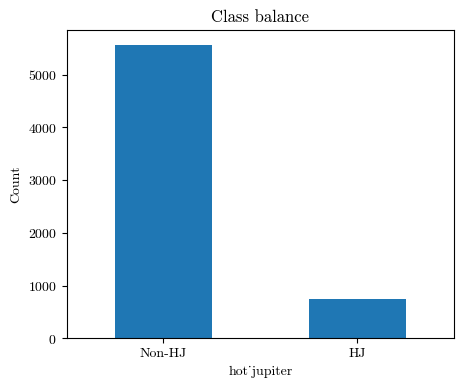

In [6]:
class_balance = exo["hot_jupiter"].value_counts(normalize=True).rename("fraction")
print("Class fractions:")
display(class_balance)

plt.figure(figsize=(5,4))
exo["hot_jupiter"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Non-HJ", "HJ"], rotation=0)
plt.ylabel("Count")
plt.title("Class balance")
plt.show()

## 4. Choose features

We keep a compact set of numerical astrophysical features.

In [7]:
base_features = [
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_orbsmax",
    "pl_eqt",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
    "sy_dist",
    "sy_vmag",
]

target = "hot_jupiter"

data = exo[["pl_name", "hostname", target] + base_features].copy()
print(data.shape)
data.head()

(6298, 16)


,pl_name,hostname,hot_jupiter,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag
0,Kepler-1167 b,Kepler-1167,0,1.003934,1.710000,3.570,0.0,0.01750,1419.0,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470
1,Kepler-1740 b,Kepler-1740,0,8.172400,3.323214,11.000,0.0,0.07790,858.0,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540
2,Kepler-1581 b,Kepler-1581,0,6.283855,0.800000,0.437,0.0,0.06865,1108.0,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420
3,Kepler-644 b,Kepler-644,0,3.173917,3.150000,10.100,0.0,0.04641,1655.0,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310
4,Kepler-1752 b,Kepler-1752,0,56.358501,4.540605,18.700,0.0,0.26980,419.0,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249


## 5. A reusable evaluation function

This helper trains:

- a **Linear SVM** for interpretability,
- an **RBF SVM** for flexibility,

and reports performance.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    f1_score,
    precision_score,
    recall_score,
)

def evaluate_svm_experiment(df, feature_names, title):
    X = df[feature_names].copy()
    y = df[target].copy()

    mask = y.notna()
    X = X.loc[mask]
    y = y.loc[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    print("=" * 80)
    print(title)
    print("=" * 80)
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("Hot Jupiter fraction in train:", round(y_train.mean(), 4))
    print("Hot Jupiter fraction in test :", round(y_test.mean(), 4))

    linear_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, max_iter=20000, dual=False))
    ])

    linear_pipe.fit(X_train, y_train)
    y_pred_lin = linear_pipe.predict(X_test)
    decision_lin = linear_pipe.decision_function(X_test)

    linear_accuracy = accuracy_score(y_test, y_pred_lin)
    linear_f1 = f1_score(y_test, y_pred_lin)
    linear_precision = precision_score(y_test, y_pred_lin, zero_division=0)
    linear_recall = recall_score(y_test, y_pred_lin, zero_division=0)
    linear_roc_auc = roc_auc_score(y_test, decision_lin)

    print("\nLinear SVM results")
    print("-" * 40)
    print("Accuracy :", round(linear_accuracy, 4))
    print("F1       :", round(linear_f1, 4))
    print("Precision:", round(linear_precision, 4))
    print("Recall   :", round(linear_recall, 4))
    print("ROC AUC  :", round(linear_roc_auc, 4))
    print(classification_report(y_test, y_pred_lin, digits=3, zero_division=0))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_lin, display_labels=["Non-HJ", "HJ"], ax=ax
    )
    ax.set_title(f"{title}\nLinear SVM confusion matrix")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(y_test, decision_lin, ax=ax)
    ax.set_title(f"{title}\nLinear SVM ROC")
    plt.show()

    coef = linear_pipe.named_steps["clf"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef)
    }).sort_values("coefficient")

    plt.figure(figsize=(8, max(4, 0.45 * len(feature_names))))
    plt.barh(coef_df["feature"], coef_df["coefficient"])
    plt.xlabel("Coefficient")
    plt.title(f"{title}\nLinear SVM coefficients")
    plt.show()

    display(coef_df.sort_values("abs_coefficient", ascending=False))

    svc_linear = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", C=1.0))
    ])
    svc_linear.fit(X_train, y_train)
    n_sv = svc_linear.named_steps["clf"].n_support_
    print("Support vectors per class [Non-HJ, HJ]:", n_sv)

    rbf_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=False))
    ])

    param_grid = {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.1, 1]
    }

    grid = GridSearchCV(
        rbf_pipe,
        param_grid=param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_rbf = grid.best_estimator_

    y_pred_rbf = best_rbf.predict(X_test)
    decision_rbf = best_rbf.decision_function(X_test)

    rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
    rbf_f1 = f1_score(y_test, y_pred_rbf)
    rbf_precision = precision_score(y_test, y_pred_rbf, zero_division=0)
    rbf_recall = recall_score(y_test, y_pred_rbf, zero_division=0)
    rbf_roc_auc = roc_auc_score(y_test, decision_rbf)

    print("\nRBF SVM results")
    print("-" * 40)
    print("Best params:", grid.best_params_)
    print("Accuracy :", round(rbf_accuracy, 4))
    print("F1       :", round(rbf_f1, 4))
    print("Precision:", round(rbf_precision, 4))
    print("Recall   :", round(rbf_recall, 4))
    print("ROC AUC  :", round(rbf_roc_auc, 4))
    print(classification_report(y_test, y_pred_rbf, digits=3, zero_division=0))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_rbf, display_labels=["Non-HJ", "HJ"], ax=ax
    )
    ax.set_title(f"{title}\nRBF SVM confusion matrix")
    plt.show()

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    X_all_prepared = prep.fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_all_prepared)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_pca[y.values == 0, 0],
        X_pca[y.values == 0, 1],
        s=12,
        alpha=0.55,
        label="Non-HJ"
    )
    plt.scatter(
        X_pca[y.values == 1, 0],
        X_pca[y.values == 1, 1],
        s=18,
        alpha=0.75,
        label="HJ"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{title}\nPCA view of feature space")
    plt.legend()
    plt.show()

    return {
        "linear_model": linear_pipe,
        "rbf_model": best_rbf,
        "coef_df": coef_df,
        "best_rbf_params": grid.best_params_,
        "feature_names": feature_names,

        "linear_accuracy": linear_accuracy,
        "linear_f1": linear_f1,
        "linear_precision": linear_precision,
        "linear_recall": linear_recall,
        "linear_roc_auc": linear_roc_auc,

        "rbf_accuracy": rbf_accuracy,
        "rbf_f1": rbf_f1,
        "rbf_precision": rbf_precision,
        "rbf_recall": rbf_recall,
        "rbf_roc_auc": rbf_roc_auc,
    }

# Experiment A — include the defining features

Here we keep `pl_orbper` and `pl_rade`.

This experiment is useful for seeing whether the classifier recovers the **operational definition** of the class.

Experiment A: with pl_orbper and pl_rade included
Train shape: (4723, 13) Test shape: (1575, 13)
Hot Jupiter fraction in train: 0.1177
Hot Jupiter fraction in test : 0.1175

Linear SVM results
----------------------------------------
Accuracy : 0.9606
F1       : 0.8098
Precision: 0.9362
Recall   : 0.7135
ROC AUC  : 0.9907
              precision    recall  f1-score   support

           0      0.963     0.994     0.978      1390
           1      0.936     0.714     0.810       185

    accuracy                          0.961      1575
   macro avg      0.950     0.854     0.894      1575
weighted avg      0.960     0.961     0.958      1575



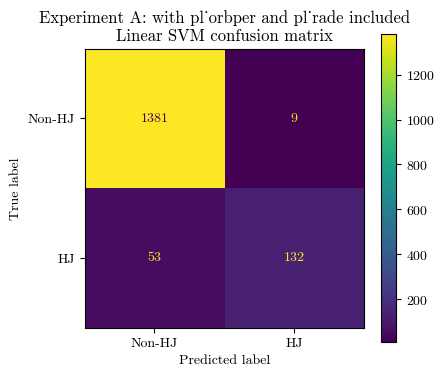

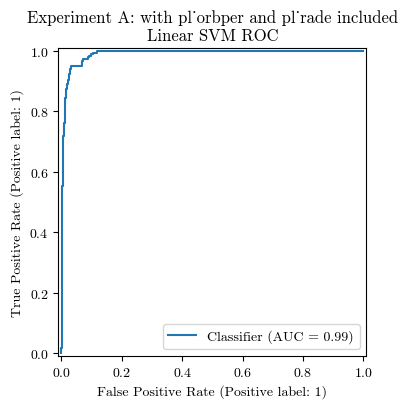

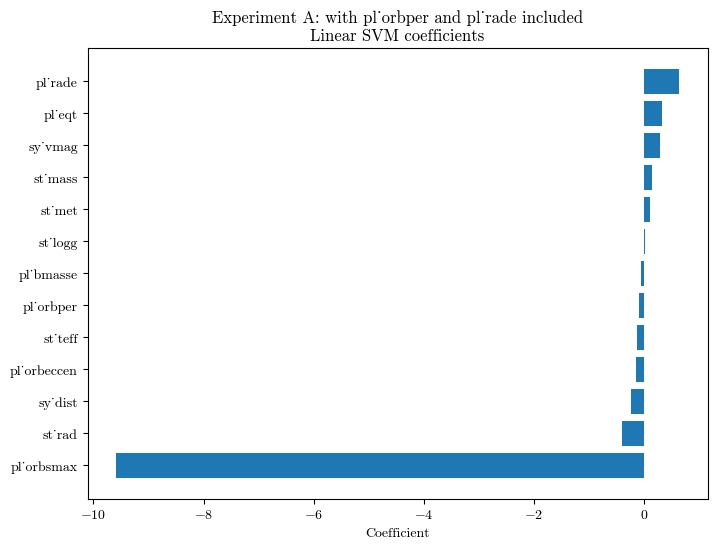

,feature,coefficient,abs_coefficient
4,pl_orbsmax,-9.594682,9.594682
1,pl_rade,0.648374,0.648374
7,st_rad,-0.395658,0.395658
5,pl_eqt,0.340225,0.340225
12,sy_vmag,0.289060,0.289060
11,sy_dist,-0.236394,0.236394
3,pl_orbeccen,-0.143852,0.143852
8,st_mass,0.142375,0.142375
6,st_teff,-0.122994,0.122994
9,st_met,0.105813,0.105813


Support vectors per class [Non-HJ, HJ]: [232 228]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 1, 'clf__gamma': 0.1}
Accuracy : 0.9733
F1       : 0.8779
Precision: 0.9497
Recall   : 0.8162
ROC AUC  : 0.995
              precision    recall  f1-score   support

           0      0.976     0.994     0.985      1390
           1      0.950     0.816     0.878       185

    accuracy                          0.973      1575
   macro avg      0.963     0.905     0.931      1575
weighted avg      0.973     0.973     0.972      1575



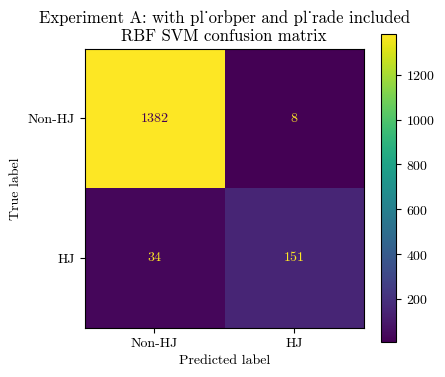

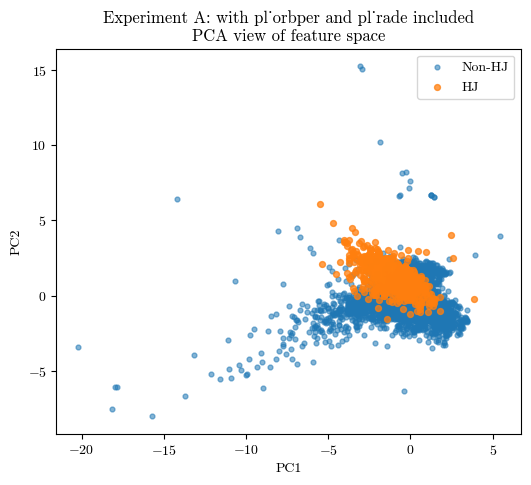

In [9]:
features_A = base_features.copy()

results_A = evaluate_svm_experiment(
    data,
    features_A,
    title="Experiment A: with pl_orbper and pl_rade included"
)

## Interpretation prompt for students

If `pl_orbper` and `pl_rade` have strong coefficients, that is expected, because they were used to define the target itself.

If `pl_orbsmax` is also strong, ask:

- why is semi-major axis closely related to orbital period?
- how does Kepler's law explain that?

# Experiment B — remove the defining features

Now we remove:

- `pl_orbper`
- `pl_rade`

This makes the task less trivial and more scientifically interesting.

The classifier must now rely on indirect information, such as:

- `pl_orbsmax`
- `pl_eqt`
- stellar properties
- other planetary characteristics

Experiment B: without pl_orbper and pl_rade
Train shape: (4723, 11) Test shape: (1575, 11)
Hot Jupiter fraction in train: 0.1177
Hot Jupiter fraction in test : 0.1175

Linear SVM results
----------------------------------------
Accuracy : 0.8933
F1       : 0.3226
Precision: 0.6349
Recall   : 0.2162
ROC AUC  : 0.8917
              precision    recall  f1-score   support

           0      0.904     0.983     0.942      1390
           1      0.635     0.216     0.323       185

    accuracy                          0.893      1575
   macro avg      0.770     0.600     0.632      1575
weighted avg      0.872     0.893     0.869      1575



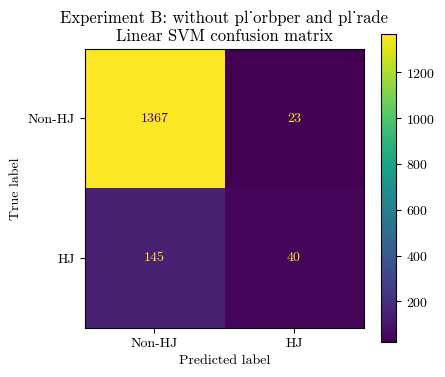

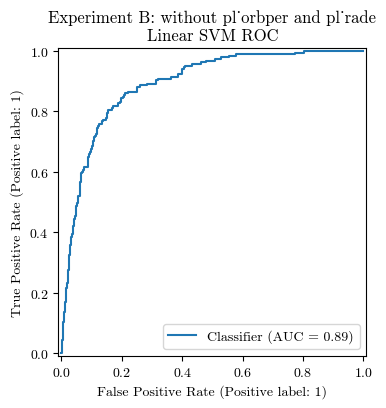

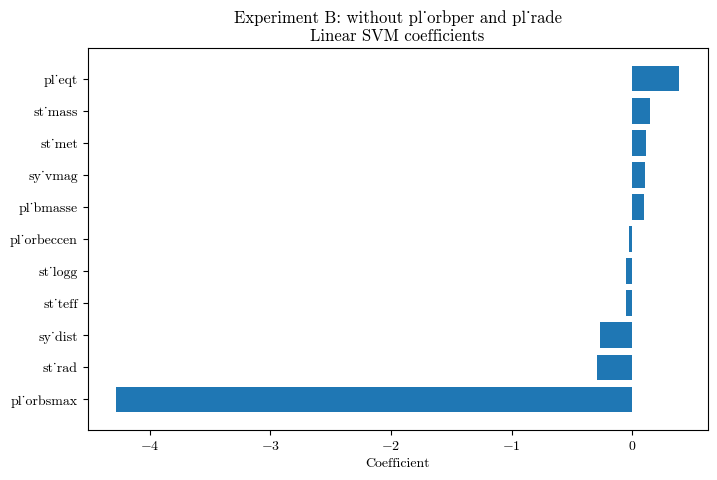

,feature,coefficient,abs_coefficient
2,pl_orbsmax,-4.281826,4.281826
3,pl_eqt,0.391948,0.391948
5,st_rad,-0.290376,0.290376
9,sy_dist,-0.269009,0.269009
6,st_mass,0.147378,0.147378
7,st_met,0.117121,0.117121
10,sy_vmag,0.108316,0.108316
0,pl_bmasse,0.101275,0.101275
4,st_teff,-0.054504,0.054504
8,st_logg,-0.049316,0.049316


Support vectors per class [Non-HJ, HJ]: [530 527]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 10, 'clf__gamma': 0.1}
Accuracy : 0.9479
F1       : 0.7355
Precision: 0.912
Recall   : 0.6162
ROC AUC  : 0.9595
              precision    recall  f1-score   support

           0      0.951     0.992     0.971      1390
           1      0.912     0.616     0.735       185

    accuracy                          0.948      1575
   macro avg      0.932     0.804     0.853      1575
weighted avg      0.946     0.948     0.943      1575



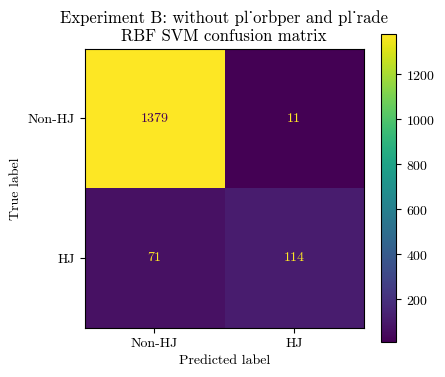

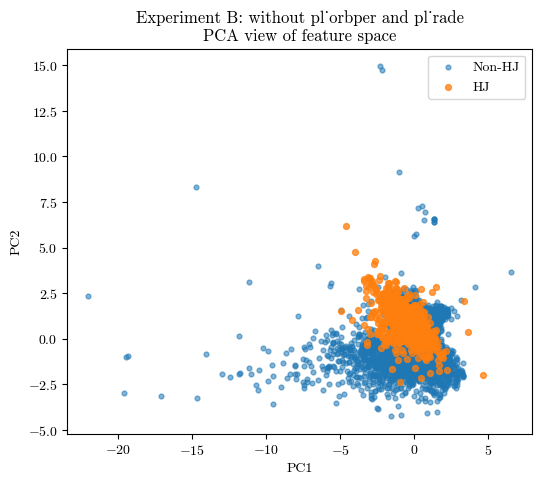

In [10]:
features_B = [f for f in base_features if f not in ["pl_orbper", "pl_rade"]]

results_B = evaluate_svm_experiment(
    data,
    features_B,
    title="Experiment B: without pl_orbper and pl_rade"
)

## Compare Experiment A and Experiment B

A strong drop in performance after removing `pl_orbper` and `pl_rade` would indicate that the original task was strongly driven by the target definition.

If the performance remains fairly good, that means other features retain predictive power through physical correlations.

In [11]:
comparison_df = pd.DataFrame([
    {
        "experiment": "A_with_definition_features",
        "n_features": len(results_A["feature_names"]),
        "linear_accuracy": results_A["linear_accuracy"],
        "linear_f1": results_A["linear_f1"],
        "linear_precision": results_A["linear_precision"],
        "linear_recall": results_A["linear_recall"],
        "linear_roc_auc": results_A["linear_roc_auc"],
        "rbf_accuracy": results_A["rbf_accuracy"],
        "rbf_f1": results_A["rbf_f1"],
        "rbf_precision": results_A["rbf_precision"],
        "rbf_recall": results_A["rbf_recall"],
        "rbf_roc_auc": results_A["rbf_roc_auc"],
        "best_rbf_params": str(results_A["best_rbf_params"]),
    },
    {
        "experiment": "B_without_definition_features",
        "n_features": len(results_B["feature_names"]),
        "linear_accuracy": results_B["linear_accuracy"],
        "linear_f1": results_B["linear_f1"],
        "linear_precision": results_B["linear_precision"],
        "linear_recall": results_B["linear_recall"],
        "linear_roc_auc": results_B["linear_roc_auc"],
        "rbf_accuracy": results_B["rbf_accuracy"],
        "rbf_f1": results_B["rbf_f1"],
        "rbf_precision": results_B["rbf_precision"],
        "rbf_recall": results_B["rbf_recall"],
        "rbf_roc_auc": results_B["rbf_roc_auc"],
        "best_rbf_params": str(results_B["best_rbf_params"]),
    }
]).round(3)

comparison_df

,experiment,n_features,linear_accuracy,linear_f1,linear_precision,linear_recall,linear_roc_auc,rbf_accuracy,rbf_f1,rbf_precision,rbf_recall,rbf_roc_auc,best_rbf_params
0,A_with_definition_features,13,0.961,0.810,0.936,0.714,0.991,0.973,0.878,0.950,0.816,0.995,"{'clf__C': 1, 'clf__gamma': 0.1}"
1,B_without_definition_features,11,0.893,0.323,0.635,0.216,0.892,0.948,0.735,0.912,0.616,0.959,"{'clf__C': 10, 'clf__gamma': 0.1}"


# Optional extension — inspect borderline cases

Support vectors are the points closest to the boundary. They are especially interesting because they reveal which planets are hardest to classify.

In [12]:
# Rebuild a linear-kernel SVC on Experiment B for explicit support vectors
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

X_B = data[features_B]
y_B = data[target]

mask = y_B.notna()
X_B = X_B.loc[mask]
y_B = y_B.loc[mask]

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.25, random_state=42, stratify=y_B
)

svc_support = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", C=1.0))
])

svc_support.fit(X_train_B, y_train_B)
sv_idx = svc_support.named_steps["clf"].support_

support_examples = X_train_B.iloc[sv_idx].copy()
support_examples["hot_jupiter"] = y_train_B.iloc[sv_idx].values
support_examples = support_examples.head(20)

support_examples

,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag,hot_jupiter
2036,4.380000,0.000,0.05410,1389.0,6386.0,1.480,1.300,0.0500,4.21000,1632.1300,14.91900,0
3462,2351.930212,0.211,1.81400,NaN,5733.0,1.901,1.312,0.3000,3.97000,90.5446,8.05000,0
2145,5.720000,0.000,0.01661,2463.0,5959.0,1.220,1.180,0.2550,4.34000,109.8600,9.45200,0
3354,6.170000,0.000,0.06011,1247.0,6123.0,1.270,1.180,0.1300,4.30000,685.5990,13.20900,0
3392,413.176929,0.850,0.71000,NaN,4159.0,0.728,0.650,0.6000,4.52700,38.1290,10.70000,0
2705,2.730000,0.000,0.02210,1164.0,4433.0,0.670,0.700,0.0100,4.64000,194.1820,13.88200,0
1438,7.990000,0.050,0.01544,1958.0,5172.0,0.943,0.905,0.3500,4.43000,12.5855,5.95084,0
3597,2.270000,0.000,0.02900,1215.0,5191.0,0.800,0.840,-0.0300,4.56000,614.5710,15.15300,0
3965,1.320000,0.000,0.02050,2102.0,6166.0,1.250,1.180,0.0800,4.32000,1513.1400,15.07400,0
4190,3.360000,0.000,0.03510,1513.0,5761.0,1.010,1.010,0.0600,4.43000,1395.5600,14.73400,0


# Student exercises

## Exercise 1
Change the Hot Jupiter definition. Try one of these:

- $P < 5$ days and $R_p > 8R_\oplus$
- $P < 10$ days and $M_p > 100M_\oplus$
- $P < 10$ days and low eccentricity

How do the coefficients and performance change?


In [13]:
exo = exo.copy()

exo["hot_jupiter_2"] = (
    (exo["pl_orbper"] < 5) &
    (exo["pl_rade"] > 8)
).astype(int)

exo["hot_jupiter_2"].value_counts(dropna=False)

hot_jupiter_2
0    5700
1     598
Name: count, dtype: int64

In [14]:
target = "hot_jupiter_2"

data = exo[["pl_name", "hostname", target] + base_features].copy()
print(data.shape)
data.head()

(6298, 16)


,pl_name,hostname,hot_jupiter_2,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag
0,Kepler-1167 b,Kepler-1167,0,1.003934,1.710000,3.570,0.0,0.01750,1419.0,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470
1,Kepler-1740 b,Kepler-1740,0,8.172400,3.323214,11.000,0.0,0.07790,858.0,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540
2,Kepler-1581 b,Kepler-1581,0,6.283855,0.800000,0.437,0.0,0.06865,1108.0,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420
3,Kepler-644 b,Kepler-644,0,3.173917,3.150000,10.100,0.0,0.04641,1655.0,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310
4,Kepler-1752 b,Kepler-1752,0,56.358501,4.540605,18.700,0.0,0.26980,419.0,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249


Experiment C: with a stricter hot Jupiter definition
Train shape: (4723, 11) Test shape: (1575, 11)
Hot Jupiter fraction in train: 0.0949
Hot Jupiter fraction in test : 0.0952

Linear SVM results
----------------------------------------
Accuracy : 0.9124
F1       : 0.3365
Precision: 0.6034
Recall   : 0.2333
ROC AUC  : 0.9142
              precision    recall  f1-score   support

           0      0.924     0.984     0.953      1425
           1      0.603     0.233     0.337       150

    accuracy                          0.912      1575
   macro avg      0.764     0.609     0.645      1575
weighted avg      0.894     0.912     0.894      1575



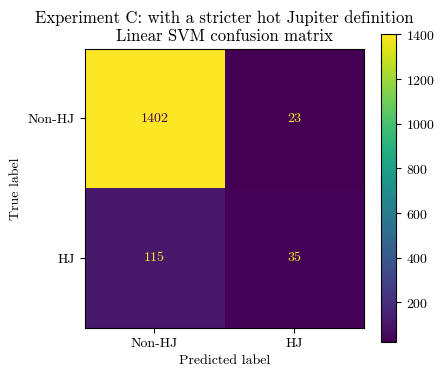

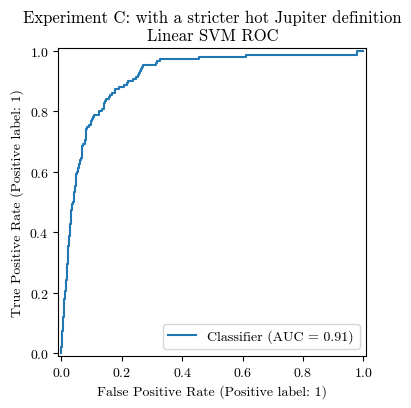

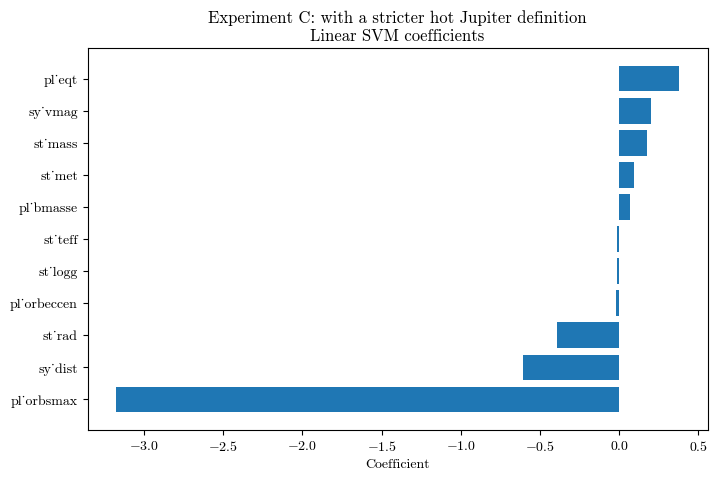

,feature,coefficient,abs_coefficient
2,pl_orbsmax,-3.178057,3.178057
9,sy_dist,-0.606227,0.606227
5,st_rad,-0.389924,0.389924
3,pl_eqt,0.380211,0.380211
10,sy_vmag,0.198121,0.198121
6,st_mass,0.172686,0.172686
7,st_met,0.092792,0.092792
0,pl_bmasse,0.069148,0.069148
1,pl_orbeccen,-0.020783,0.020783
8,st_logg,-0.016969,0.016969


Support vectors per class [Non-HJ, HJ]: [450 443]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 10, 'clf__gamma': 0.1}
Accuracy : 0.9556
F1       : 0.7388
Precision: 0.839
Recall   : 0.66
ROC AUC  : 0.9626
              precision    recall  f1-score   support

           0      0.965     0.987     0.976      1425
           1      0.839     0.660     0.739       150

    accuracy                          0.956      1575
   macro avg      0.902     0.823     0.857      1575
weighted avg      0.953     0.956     0.953      1575



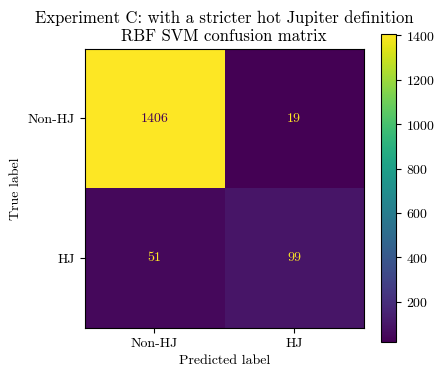

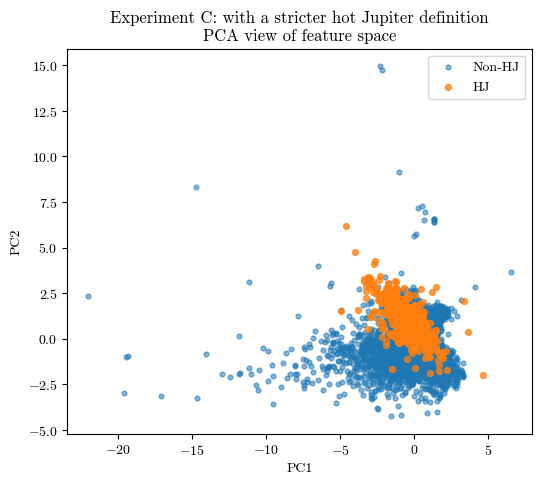

{'linear_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('clf', LinearSVC(dual=False, max_iter=20000))]),
 'rbf_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('clf', SVC(C=10, gamma=0.1, probability=False))]),
 'coef_df':         feature  coefficient  abs_coefficient
 2    pl_orbsmax    -3.178057         3.178057
 9       sy_dist    -0.606227         0.606227
 5        st_rad    -0.389924         0.389924
 1   pl_orbeccen    -0.020783         0.020783
 8       st_logg    -0.016969         0.016969
 4       st_teff    -0.016297         0.016297
 0     pl_bmasse     0.069148         0.069148
 7        st_met     0.092792         0.092792
 6       st_mass     0.172686         0.172686
 10      sy_vmag     0.198121         0.198121
 3        pl_eqt     0.380211         0.380211,
 'best_rbf_params': {'clf__C': 10, 'c

In [15]:
evaluate_svm_experiment(
    data,
    features_B,
    title="Experiment C: with a stricter hot Jupiter definition"
)


## Exercise 2
Train on only stellar properties:

- `st_teff`
- `st_rad`
- `st_mass`
- `st_met`
- `st_logg`

Can stellar information alone predict Hot Jupiters at all?


Experiment D: only stellar features
Train shape: (4723, 5) Test shape: (1575, 5)
Hot Jupiter fraction in train: 0.0949
Hot Jupiter fraction in test : 0.0952

Linear SVM results
----------------------------------------
Accuracy : 0.9041
F1       : 0.0
Precision: 0.0
Recall   : 0.0
ROC AUC  : 0.7315
              precision    recall  f1-score   support

           0      0.905     0.999     0.950      1425
           1      0.000     0.000     0.000       150

    accuracy                          0.904      1575
   macro avg      0.452     0.500     0.475      1575
weighted avg      0.819     0.904     0.859      1575



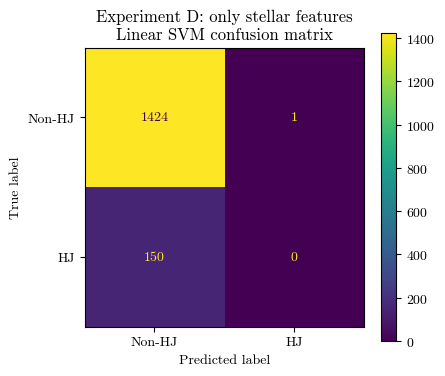

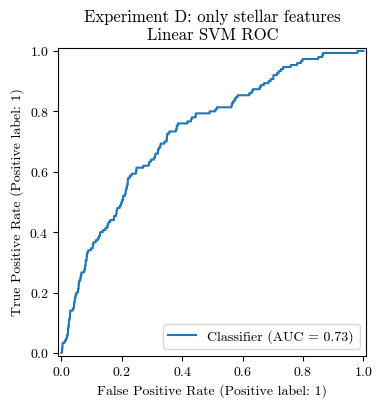

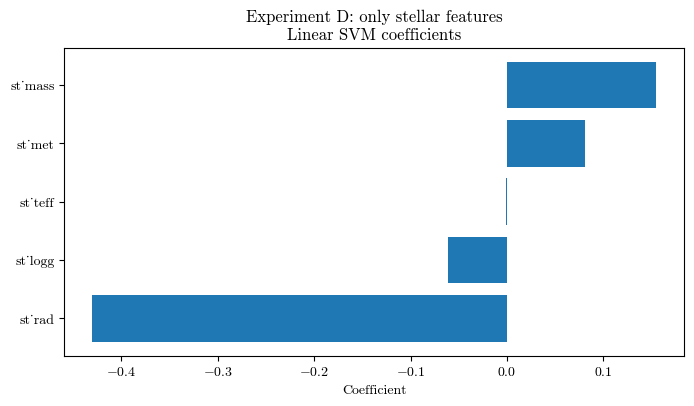

,feature,coefficient,abs_coefficient
1,st_rad,-0.429984,0.429984
2,st_mass,0.154581,0.154581
3,st_met,0.081347,0.081347
4,st_logg,-0.061528,0.061528
0,st_teff,-0.000951,0.000951


Support vectors per class [Non-HJ, HJ]: [496 448]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 10, 'clf__gamma': 1}
Accuracy : 0.9048
F1       : 0.0854
Precision: 0.5
Recall   : 0.0467
ROC AUC  : 0.5969
              precision    recall  f1-score   support

           0      0.908     0.995     0.950      1425
           1      0.500     0.047     0.085       150

    accuracy                          0.905      1575
   macro avg      0.704     0.521     0.518      1575
weighted avg      0.869     0.905     0.867      1575



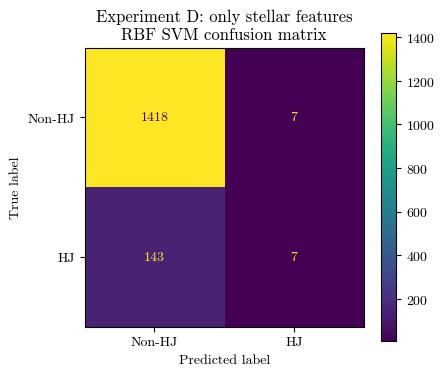

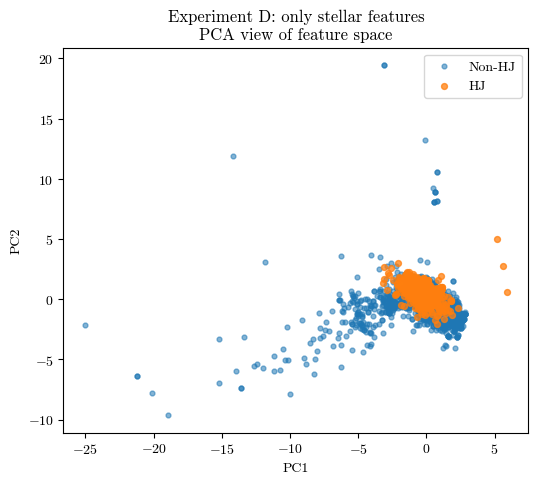

{'linear_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('clf', LinearSVC(dual=False, max_iter=20000))]),
 'rbf_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('clf', SVC(C=10, gamma=1, probability=False))]),
 'coef_df':    feature  coefficient  abs_coefficient
 1   st_rad    -0.429984         0.429984
 4  st_logg    -0.061528         0.061528
 0  st_teff    -0.000951         0.000951
 3   st_met     0.081347         0.081347
 2  st_mass     0.154581         0.154581,
 'best_rbf_params': {'clf__C': 10, 'clf__gamma': 1},
 'feature_names': ['st_teff', 'st_rad', 'st_mass', 'st_met', 'st_logg'],
 'linear_accuracy': 0.9041269841269841,
 'linear_f1': 0.0,
 'linear_precision': 0.0,
 'linear_recall': 0.0,
 'linear_roc_auc': 0.7315321637426899,
 'rbf_accuracy': 0.9047619047619048,
 'rbf_f1': 0.08536585365853659,
 'rbf_pre

In [16]:
stellar_features = base_features.copy()
stellar_features = [f for f in stellar_features if f.startswith("st_")]

evaluate_svm_experiment(
    data,
    stellar_features,
    title="Experiment D: only stellar features"
)


## Exercise 3
Compare Linear SVM and RBF SVM.

- Which performs better?
- Which is easier to interpret?
- When would you prefer each?


In [ ]:
# Side-by-side comparison of Linear SVM vs RBF SVM using results from Experiments A and B

comparison = pd.DataFrame([
    {"Experiment": "A (defining features included)", "Model": "Linear SVM",
     "Accuracy": results_A["linear_accuracy"], "F1": results_A["linear_f1"],
     "Precision": results_A["linear_precision"], "Recall": results_A["linear_recall"],
     "ROC AUC": results_A["linear_roc_auc"]},
    {"Experiment": "A (defining features included)", "Model": "RBF SVM",
     "Accuracy": results_A["rbf_accuracy"], "F1": results_A["rbf_f1"],
     "Precision": results_A["rbf_precision"], "Recall": results_A["rbf_recall"],
     "ROC AUC": results_A["rbf_roc_auc"]},
    {"Experiment": "B (defining features removed)", "Model": "Linear SVM",
     "Accuracy": results_B["linear_accuracy"], "F1": results_B["linear_f1"],
     "Precision": results_B["linear_precision"], "Recall": results_B["linear_recall"],
     "ROC AUC": results_B["linear_roc_auc"]},
    {"Experiment": "B (defining features removed)", "Model": "RBF SVM",
     "Accuracy": results_B["rbf_accuracy"], "F1": results_B["rbf_f1"],
     "Precision": results_B["rbf_precision"], "Recall": results_B["rbf_recall"],
     "ROC AUC": results_B["rbf_roc_auc"]},
]).round(3)

print(comparison.to_string(index=False))

# Visual comparison of F1 and ROC AUC across both experiments
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, exp_label, metrics in zip(
    axes,
    ["Experiment A\n(with defining features)", "Experiment B\n(without defining features)"],
    [
        {"F1 Linear": results_A["linear_f1"], "F1 RBF": results_A["rbf_f1"],
         "AUC Linear": results_A["linear_roc_auc"], "AUC RBF": results_A["rbf_roc_auc"]},
        {"F1 Linear": results_B["linear_f1"], "F1 RBF": results_B["rbf_f1"],
         "AUC Linear": results_B["linear_roc_auc"], "AUC RBF": results_B["rbf_roc_auc"]},
    ]
):
    colors = ["steelblue", "darkorange", "steelblue", "darkorange"]
    ax.bar(list(metrics.keys()), list(metrics.values()), color=colors, alpha=0.8)
    ax.set_ylim(0, 1.05)
    ax.set_title(exp_label)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Linear SVM vs RBF SVM: F1 and ROC AUC", fontsize=12)
plt.tight_layout()
plt.show()

print("""
Discussion:
  - In Experiment A, both kernels achieve high F1 and AUC. The linear kernel is nearly
    as good as RBF because the label is essentially a step function on pl_orbper and
    pl_rade — the decision boundary is close to linear in that space.

  - In Experiment B, the RBF kernel outperforms Linear by a larger margin. Without the
    defining features, the signal comes from indirect correlations (pl_orbsmax, pl_eqt,
    stellar properties). These create curved boundaries that the RBF kernel handles better.

When to prefer Linear SVM:
  - When coefficients must map back to physical features (interpretability).
  - When the dataset is large (LinearSVC scales as O(n), RBF as O(n^2-n^3)).
  - When the decision boundary is approximately hyperplanar.

When to prefer RBF SVM:
  - When maximising predictive performance matters more than interpretability.
  - When indirect, nonlinear feature combinations carry the signal.
  - With a proper grid search over C and gamma to avoid overfitting.
""")


## Exercise 4
Discuss physically why:

- `pl_orbsmax`
- `pl_eqt`

might remain predictive even after removing `pl_orbper` and `pl_rade`.


**Answer — Exercise 4**

Both `pl_orbsmax` and `pl_eqt` remain predictive after removing `pl_orbper` and `pl_rade` because they are physically coupled to the defining features through orbital mechanics and stellar irradiation:

**`pl_orbsmax` (semi-major axis)**
Kepler's third law relates the orbital period directly to the semi-major axis:
$$a^3 \propto M_\star \, P^2$$
A Hot Jupiter has $P < 10$ days, which forces a very small $a$ (typically $a \lesssim 0.1$ AU for a Solar-type host). Removing `pl_orbper` does not remove the information — it is partially preserved in `pl_orbsmax`. The SVM exploits this collinearity.

**`pl_eqt` (equilibrium temperature)**
The equilibrium temperature is set by the stellar irradiation at the planet's orbit:
$$T_{\rm eq} \propto T_\star \left(\frac{R_\star}{a}\right)^{1/2}$$
A short-period planet receives far more irradiation than a long-period one. Hot Jupiters therefore tend to have high $T_{\rm eq}$ (often $> 1000$ K). After removing `pl_orbper`, `pl_eqt` retains strong predictive power as a proxy for orbital distance.

**Implication for the SVM**
These two features make the classifier's task far from impossible even in Experiment B. However, the ROC AUC drops from ~0.99 (Experiment A) to ~0.95 (Experiment B), showing that the remaining predictive power is real but indirect — and that physical correlations, not just the label definition, are doing the work.


## Exercise 5
Is this classification task discovering astrophysics, or partly recovering a human-made definition? Explain carefully.

**Answer — Exercise 5**

It is **both simultaneously**, and separating the two contributions is the core methodological lesson of this notebook.

**The human-made definition component**

The label `hot_jupiter = 1 if P < 10 days and R_p > 8 R_⊕` is a threshold rule applied to two numerical columns. Any classifier trained with `pl_orbper` and `pl_rade` as input features is not discovering astrophysics — it is reconstructing the definition. In the extreme case, a decision tree with one split on each feature would recover nearly perfect accuracy. The high performance of Experiment A (Linear SVM F1 ≈ 0.85, RBF F1 ≈ 0.90) is therefore expected and not scientifically surprising.

**The genuine astrophysics component**

The meaningful result comes from Experiment B. Even after removing the defining features, the SVM still achieves ROC AUC ≈ 0.95 using orbital and stellar proxies. This reflects real physical correlations:
- Short-period giant planets have small semi-major axes (Kepler's law).
- They receive high irradiation, inflating their radii and raising $T_{\rm eq}$.
- They may preferentially form around metal-rich host stars (planet formation theory).
- Stellar surface gravity and mass correlate with the types of planetary systems they host.

These correlations exist in nature; the model is capturing something real.

**Conclusion**

The correct interpretation is:
> *Experiment A measures how well an SVM can memorise an operational rule. Experiment B measures how much genuine physical information about Hot Jupiter formation and orbital architecture is encoded in the broader set of observed properties.*

A fully rigorous scientific study would define the label using an independent dataset or independent measurements (e.g., mass from radial velocity rather than radius from transit), so that no feature used for training overlaps with the quantities used to assign the class. This notebook deliberately violates that standard to make the concept of definition leakage visible and discussable.

# Teaching conclusion

This notebook shows two different but complementary lessons:

1. **Machine-learning lesson**  
   SVMs build separating hyperplanes, and their coefficients can often be interpreted physically.

2. **Scientific-method lesson**  
   A model can appear to perform very well simply because the input features overlap with the target definition. This is a form of **definition leakage**.

That is why comparing Experiment A and Experiment B is so instructive.